# EverFlavor AI - Stores, Restaurants and Products

**Team:** EverGlow
**Course:** ITAI 2277
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System

> **Status: built.** Every section runs without a key; the code is in `src/everflavor/stores.py` and is
> tested in `tests/test_stores.py`. **Google Places** (section 2) switches on by itself once
> `GOOGLE_PLACES_API_KEY` is in Colab Secrets or `config/.env`; until then it is skipped and OpenStreetMap
> is the place source. The pilot area and cuisines are placeholders until the team decides (section 7).

---

## Purpose

The Sourcing Agent answers "where can I buy this?" and "where can I eat this?". This notebook collects:

- **Places:** grocery stores and restaurants near a location, with the cuisine they serve or the kind of
  products they sell (Google Places and OpenStreetMap).
- **Products by country:** packaged products, the brand, the country they come from and the countries
  and stores that sell them (Open Food Facts). This lets the agent suggest the brand a person knows from
  home, not just "soy sauce".
- **A link between the two:** recipe ingredient -> products -> stores that carry them.

**Safety rule (as in notebook 02):** anything about a specific store or restaurant (what it stocks, which
oil it fries in, whether a dish is halal) is **unverified** unless the place itself publishes it. The agent
says "check with the store" instead of stating it as a fact. Store data can add a caution, never clear a
restriction flag.

## Inputs and outputs

| | File | Made by |
|---|---|---|
| Input | `data/interim/recipes_all.parquet` (ingredients, origin country) | Notebook 01 (section 5.11) |
| Input | Google Places API, only when `GOOGLE_PLACES_API_KEY` is set | Section 2, place IDs saved in `data/raw/places_cache/` |
| Input | OpenStreetMap through the Overpass API (no key, ODbL) | Section 3, answers saved in `data/raw/osm_cache/` |
| Input | Open Food Facts product export (no key, ODbL, 7.9 GB) | Section 4: a spread sample read over the network by default, or the whole file once downloaded |
| Output | `data/processed/places.parquet` (one row per place; Google rows keep only `place_id`) | Notebook 03 (sections 2-3), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/products_by_country.parquet` (products with brand, home country and whether they are sold in the US) | Notebook 03 (section 4), saved once and reused, not stored in GitHub |
| Output | `data/processed/ingredient_products.parquet` (recipe ingredient -> products, with how they matched) | Notebook 03 (section 5), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/region_coverage_stores.csv` (how ready each origin country is for the Sourcing Agent) | Notebook 03 (section 6), rebuilt on every run, not stored in GitHub |

## Contents

1. Setup
2. Google Places: stores and restaurants
3. OpenStreetMap: a free, open second source
4. Open Food Facts: products by country of origin
5. Linking recipe ingredients to products and stores
6. Coverage by country (which regions are ready)
7. Team decisions and next steps

---

## 1. Setup

The same setup as notebooks 01 and 02: it works unchanged in Google Colab, VS Code and Antigravity.
The Google Places key is read the same way as the USDA key: Colab Secrets in Colab, `config/.env` locally
(`GOOGLE_PLACES_API_KEY`). It is never printed and `config/.env` is never committed.

In [1]:
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
%pip install -q requests pandas pyarrow fsspec aiohttp matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path

import pandas as pd

# -------------------------------------------------------
# 1. Where is this notebook running? Move to the project folder
#    (the one that holds notebooks/ and data/), as in notebook 01.
# -------------------------------------------------------
try:
    import google.colab  # noqa: F401  # pyright: ignore[reportMissingImports]  (only exists in Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def find_project_root(start):
    # Return the nearest folder at or above `start` with notebooks/ and data/, or None
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 2. The project's code (src/everflavor). If the notebook was opened on its
#    own, the missing files are downloaded from GitHub (temporary name
#    first, __init__.py last), exactly as in notebook 01.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "charts", "checks", "cooking", "cuisine", "diets", "environment",
                      "features", "flags", "freshness", "ingredients", "knowledge", "nutrition",
                      "nutrition_quality", "parsing", "pipeline", "progress", "recommend", "reporting",
                      "review", "sources", "stores", "variants"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import short_path

REFRESH_DOWNLOADS = False   # True downloads every source again instead of using the saved copy
SPLIT_FILES = {s: Path(f"data/processed/recipes_{s}.parquet") for s in ["train", "val", "test"]}
ALL_RECIPES_FILE = Path("data/interim/recipes_all.parquet")
PILOT_AREA = {"name": "Houston, TX", "lat": 29.7604, "lng": -95.3698, "radius_m": 15000}  # team decision, section 7
PLACES_CACHE = Path("data/raw/places_cache")
OSM_CACHE = Path("data/raw/osm_cache")
OFF_EXPORT_DIR = Path("data/raw/off_export")
PLACES_FILE = Path("data/processed/places.parquet")
PRODUCTS_FILE = Path("data/processed/products_by_country.parquet")
LINKS_FILE = Path("data/processed/ingredient_products.parquet")
COVERAGE_FILE = Path("data/processed/region_coverage_stores.csv")
for folder in [PLACES_CACHE, OSM_CACHE, OFF_EXPORT_DIR, Path("data/processed")]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Runtime        : {'Google Colab' if IN_COLAB else 'Local Jupyter (VS Code / Antigravity / JupyterLab)'}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
missing_inputs = [str(p) for p in [*SPLIT_FILES.values(), ALL_RECIPES_FILE] if not p.exists()]
if missing_inputs:
    print("\nMISSING notebook 01 outputs:", ", ".join(missing_inputs))
    print("Run notebook 01 first (all of Week 5), then run this notebook again.")
else:
    print("Notebook 01 outputs found.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
Notebook 01 outputs found.


In [3]:
import matplotlib.pyplot as plt

from everflavor.charts import label_bars, set_chart_style, show_figure
from everflavor.environment import get_secret, load_env_file
from everflavor.stores import (
    OFF_EXPORT_URL,
    OSM_TAGS,
    link_ingredients_to_products,
    off_products_by_country,
    osm_places,
    place_queries,
    region_coverage,
    search_places,
    suggest_where_to_buy,
)

set_chart_style()
load_env_file(PROJECT_ROOT / "config" / ".env")   # local keys; in Colab, get_secret reads Colab Secrets
recipes = pd.read_parquet(ALL_RECIPES_FILE, columns=["recipe_id", "ingredient_list", "origin_country"])
PILOT_CUISINES = ["ethiopian", "indian", "chinese", "mexican", "korean", "vietnamese", "middle eastern"]  # section 7
print(f"Pilot area: {PILOT_AREA['name']}, {PILOT_AREA['radius_m'] / 1000:g} km around the center")

Pilot area: Houston, TX, 15 km around the center


---

## 2. Google Places: Stores and Restaurants

**API:** Places API (New), Text Search and Nearby Search. Queries such as "Ethiopian grocery store",
"Korean restaurant" or "halal butcher" inside the pilot area.

**Terms of service shape the design.** Google allows apps to store the **place ID** indefinitely, but not
most other content (names, ratings, opening hours) beyond short-term caching. So:

- the saved table keeps `place_id`, the query that found it and the date;
- the agent fetches the name, address and hours **live** when it shows a result;
- the field mask asks only for what is needed (cost is per request and depends on the fields).

**Cost control:** a fixed list of queries per pilot area, results cached by query, and `REFRESH_DOWNLOADS`
off by default, the same pattern as the Open Food Facts cache.

**Table** (`places.parquet`, Google rows):

| Column | Meaning |
|---|---|
| `place_id` | Google's ID (the only Google content stored) |
| `source` | `google` |
| `query` | The search that found it ("Ethiopian grocery store") |
| `category` | `grocery`, `restaurant`, `butcher`, `bakery` ... (from the query) |
| `cuisine_hint` | The cuisine in the query; a hint, not verified |
| `retrieved` | Date of the search |

**Without a key** this section is skipped (nothing is sent to Google); add `GOOGLE_PLACES_API_KEY` to Colab Secrets or `config/.env` and run it again.

In [4]:
GOOGLE_PLACES_API_KEY = get_secret("GOOGLE_PLACES_API_KEY")
google_rows = []
if GOOGLE_PLACES_API_KEY:
    for category, cuisine, query in place_queries(PILOT_CUISINES):
        for place in search_places(query, PILOT_AREA, GOOGLE_PLACES_API_KEY, PLACES_CACHE, refresh=REFRESH_DOWNLOADS):
            google_rows.append({**place, "source": "google", "category": category, "cuisine_hint": cuisine})
    print(f"Google Places: {len(google_rows):,} results for {len(place_queries(PILOT_CUISINES))} queries (IDs only)")
else:
    print("No GOOGLE_PLACES_API_KEY: Google Places skipped; OpenStreetMap (section 3) is the place source.")
google_places = pd.DataFrame(google_rows)

No GOOGLE_PLACES_API_KEY: Google Places skipped; OpenStreetMap (section 3) is the place source.


---

## 3. OpenStreetMap: A Free, Open Second Source

**API:** Overpass API (no key). OpenStreetMap data is under the **ODbL** license: it can be stored and
used, with attribution ("© OpenStreetMap contributors"), and a database built from it must stay open.

Useful tags:

| Tag | Example |
|---|---|
| `amenity=restaurant` + `cuisine=*` | `cuisine=ethiopian`, `cuisine=korean;bbq` |
| `shop=supermarket`, `shop=convenience`, `shop=greengrocer` | Groceries |
| `shop=butcher` + `diet:halal=yes` / `diet:kosher=yes` | Halal or kosher butchers |
| `diet:vegan=*`, `diet:vegetarian=*` | Diet options at restaurants |

**Known weakness:** shops rarely say which country's products they sell (there is no standard tag for an
"Ethiopian grocery"). `name_hint` adds a name-keyword hint ("Asian Market", "Mercado", "Halal") marked as a
guess, and Google Places fills the gap. **Usage policy:** few, cached queries (the public Overpass servers
ask for fair use).

In [5]:
osm = pd.concat([osm_places(PILOT_AREA, category, OSM_CACHE, refresh=REFRESH_DOWNLOADS) for category in OSM_TAGS],
                ignore_index=True)
places = pd.concat([osm, google_places], ignore_index=True)
places.to_parquet(PLACES_FILE, index=False)
print(f"OpenStreetMap ({PILOT_AREA['name']}): " + ", ".join(f"{n:,} {c}" for c, n in osm["category"].value_counts().items()))
print(f"Saved {len(places):,} places to {PLACES_FILE}  (data: (c) OpenStreetMap contributors, ODbL)")
tagged = osm["cuisine"].map(len).gt(0).mean()
print(f"Restaurants and shops with a cuisine tag: {tagged:.0%}; with a name hint: {osm['name_hint'].ne('').mean():.0%}")
print(f"Halal tagged: {int(osm['diet_halal'].eq(True).sum())}, kosher: {int(osm['diet_kosher'].eq(True).sum())}, "
      f"vegan options: {int(osm['diet_vegan'].eq(True).sum())}")

OpenStreetMap (Houston, TX): 959 restaurant, 577 grocery, 7 butcher
Saved 1,543 places to data\processed\places.parquet  (data: (c) OpenStreetMap contributors, ODbL)
Restaurants and shops with a cuisine tag: 47%; with a name hint: 5%
Halal tagged: 10, kosher: 4, vegan options: 8


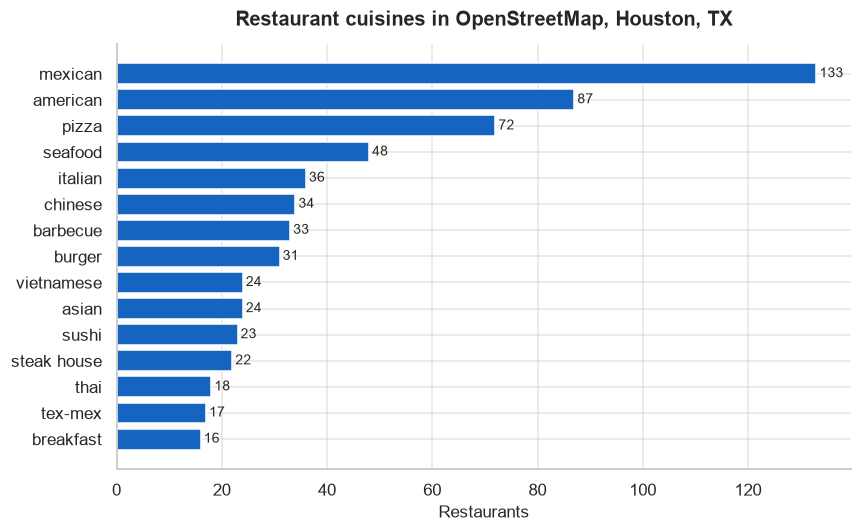

In [6]:
# Chart: the cuisines OpenStreetMap lists for restaurants in the pilot area
cuisines = osm[osm["category"] == "restaurant"]["cuisine"].explode().dropna().value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cuisines.index.str.replace("_", " "), cuisines.values, color="#1565C0")
label_bars(ax)
ax.set_xlabel("Restaurants")
ax.set_title(f"Restaurant cuisines in OpenStreetMap, {PILOT_AREA['name']}")
show_figure(fig, "nb03_01_restaurant_cuisines")

---

## 4. Open Food Facts: Products by Country of Origin

The compound-ingredient check in notebook 01 (section 5.13) showed that the **search API** is slow
(about 10 searches a minute) and often busy (HTTP 503). For thousands of products we use the **full
export** instead: one download, no rate limit.

**Source (checked 2026-10-04):** the Parquet export on Hugging Face, `openfoodfacts/product-database`,
file `food.parquet` (about 7.9 GB, 4.8 million products in about 4,700 row groups, ODbL). Parquet lets us
read only the columns below, so it fits in Colab's memory.

**Two ways to read it** (`OFF_EXPORT_MODE`):

- `"sample"` (default): read an evenly spread sample of `OFF_SAMPLE_ROW_GROUPS` row groups straight over
  the network, only the columns below (about 2 seconds per 1,000 products; 1,000 row groups is about 1 million
  products in about 30 minutes). The result is saved, so later runs take seconds.
- `"full"`: download the whole file once to `data/raw/off_export/` (never committed) and read every row group.

Fields used:

| Field | Meaning |
|---|---|
| `product_name`, `brands`, `categories_tags` | What the product is |
| `origins_tags` | Where the ingredients come from |
| `manufacturing_places_tags` | Where it is made |
| `countries_tags` | Countries where it is **sold** |
| `stores_tags` | Store chains that sell it (filled in by volunteers, incomplete) |
| `allergens_tags`, `traces_tags`, `ingredients_analysis_tags` | Allergens, "may contain", vegan / vegetarian / palm oil status |

**Table** (`products_by_country.parquet`): one row per product with the fields above, plus
`home_country` (origin, or the manufacturing country when origin is empty) and `sold_in_us` (true when
`countries_tags` has `en:united-states`).

In [7]:
OFF_EXPORT_MODE = "sample"          # "sample" (network, no big download) or "full" (downloads 7.9 GB once)
OFF_SAMPLE_ROW_GROUPS = 1000

if OFF_EXPORT_MODE == "full":
    from everflavor.sources import download_file
    export_file = OFF_EXPORT_DIR / "food.parquet"
    if not export_file.exists():
        print("Downloading the Open Food Facts export (7.9 GB) ...")
        download_file(OFF_EXPORT_URL, export_file, timeout=3600)
    products = off_products_by_country(export_file, PRODUCTS_FILE, n_row_groups=None, refresh=REFRESH_DOWNLOADS)
else:
    products = off_products_by_country(OFF_EXPORT_URL, PRODUCTS_FILE, n_row_groups=OFF_SAMPLE_ROW_GROUPS,
                                       refresh=REFRESH_DOWNLOADS)
print(f"{len(products):,} products ({OFF_EXPORT_MODE}); sold in the US: {products['sold_in_us'].mean():.0%}; "
      f"with a home country: {products['home_country'].ne('').mean():.0%}")
from_abroad = products[products["sold_in_us"] & products["home_country"].ne("")
                       & products["home_country"].ne("United States")]
print("\nHome countries of products sold in the US (from abroad):")
print(from_abroad["home_country"].value_counts().head(12).to_string())

1,020,381 products (sample); sold in the US: 21%; with a home country: 5%

Home countries of products sold in the US (from abroad):
home_country
Canada            112
Mexico             65
Italy              52
China              47
France             44
India              29
United Kingdom     24
Thailand           24
Germany            23
Turkey             19
Spain              18
Argentina          17


---

## 5. Linking Recipe Ingredients to Products and Stores

1. **Ingredient -> products:** match normalized ingredient names (notebook 01) to product categories and
   names, the same name matching as the compound-ingredient check.
2. **Products -> home country:** "this Sichuan recipe needs doubanjiang; these brands come from China
   and are sold in the US".
3. **Products -> stores:** from `stores_tags` where it exists; otherwise only "try an Asian grocery near
   you" from the places in sections 2-3. Never "store X has it".

**Table** (`ingredient_products.parquet`): `ingredient`, `code`, `brand`, `home_country`,
`sold_in_us`, `match` (`exact` / `category`), `confidence`.

In [8]:
ingredient_counts = pd.Series([i for items in recipes["ingredient_list"] for i in items]).value_counts()
common_ingredients = ingredient_counts[ingredient_counts >= 200].index.tolist()
links = link_ingredients_to_products(common_ingredients, products)
links.to_parquet(LINKS_FILE, index=False)
print(f"{links['ingredient'].nunique():,} of {len(common_ingredients):,} common ingredients link to products "
      f"({len(links):,} links); match: " + ", ".join(f"{m} {n:,}" for m, n in links["match"].value_counts().items()))

for ingredient, country in [("soy sauce", "China"), ("fish sauce", "Thailand"), ("tortilla", "Mexico"),
                            ("feta cheese", "Greece"), ("basmati rice", "India")]:
    tip = suggest_where_to_buy(ingredient, country, links, places)
    home = tip["home_brands"] or tip["home_brands_elsewhere"]
    print(f"\n{ingredient} ({country}): brands from {country}: {home[:3] or '-'}"
          f"{'' if tip['home_brands'] or not home else ' (not marked as sold in the US)'}; "
          f"sold in the US: {tip['other_brands_sold_in_us'][:3] or '-'}")
    print(f"  stores to try ({tip['store_match']} match): {tip['stores_to_try'][:3] or 'none found in OpenStreetMap'}")
print(f"\nEvery store suggestion says: {tip['note']}")

1,043 of 1,185 common ingredients link to products (28,864 links); match: category 19,187, name 9,677

soy sauce (China): brands from China: -; sold in the US: ['Caribbean Trading Corporation Of Orlando', 'Mandarin Soy Sauce Inc', 'WAN JA SHAN']
  stores to try (none match): none found in OpenStreetMap

fish sauce (Thailand): brands from Thailand: ['Tiparos']; sold in the US: ['A Taste Of Thai', '9999', 'Golden Boy,  Golden Boy Brand']
  stores to try (none match): none found in OpenStreetMap

tortilla (Mexico): brands from Mexico: ['Metztli'] (not marked as sold in the US); sold in the US: ['OLÉ', "Rudi's Organic Bakery", 'Tortilla Fresca']
  stores to try (region match): ['Fiesta Mart', 'Mi Tienda', 'Supermercado El Rancho']

feta cheese (Greece): brands from Greece: -; sold in the US: ['MT VIKOS']
  stores to try (none match): none found in OpenStreetMap

basmati rice (India): brands from India: -; sold in the US: ['RICESELECT', 'Riceselect, Rice Select', 'Rice Select']
  stores to 

---

## 6. Coverage by Country

For each origin country in the recipes: how many recipes, how many of their ingredients link to a product,
how many products come from that country and are sold in the US, and how many nearby places serve that
cuisine. This says which regions are ready for the Sourcing Agent and where data is thin.

In [9]:
coverage = region_coverage(recipes, links, products, places)
coverage.to_csv(COVERAGE_FILE, index=False)
print(f"Saved {len(coverage)} countries to {COVERAGE_FILE}")
coverage.head(15)

Saved 91 countries to data\processed\region_coverage_stores.csv


,origin_country,recipes,ingredients_linked_pct,home_products_sold_in_us,nearby_places
0,United States,131726,100.0,691,88
1,Italy,25077,100.0,52,36
2,Mexico,14825,100.0,65,133
3,France,8682,100.0,44,10
4,India,7469,100.0,29,13
5,China,6016,100.0,47,34
6,United Kingdom,4698,100.0,24,2
7,Canada,4628,100.0,112,0
8,Greece,4405,100.0,6,5
9,Australia,2765,100.0,10,0


---

## 7. Team Decisions and Next Steps

**Decisions still open:**

1. **Pilot area:** the city and radius for store searches (the setup cell has Houston as a placeholder).
2. **Pilot cuisines:** which countries first. By recipe count in notebook 01: United States 131k, Italy 25k,
   Mexico 15k, France 8.7k, India 7.5k, China 6.0k, United Kingdom 4.7k, Canada 4.6k, Greece 4.4k,
   Australia 2.8k, Thailand 2.5k, Japan 2.3k, Spain 1.9k, Morocco 1.6k.
   Countries with fewer recipes are where sourcing help matters most, so the pilot could mix both.

3. **Google Places budget:** a monthly cap for API calls, before adding the key.
4. **Open Food Facts:** keep the network sample, or download the full export (7.9 GB) for every product.

**Built:** OpenStreetMap and Open Food Facts run without a key; Google Places is ready and waits for the key.

---

## Plan status

What is built and what still needs a decision or a key.

In [10]:
PLAN = pd.DataFrame([
    ("2 Google Places search", "built; runs once GOOGLE_PLACES_API_KEY is set" if not GOOGLE_PLACES_API_KEY
     else f"built: {len(google_places):,} place IDs"),
    ("3 OpenStreetMap places", f"built: {len(osm):,} places in {PILOT_AREA['name']}"),
    ("4 Open Food Facts export", f"built: {len(products):,} products ({OFF_EXPORT_MODE})"),
    ("5 Ingredient -> product -> store", f"built: {links['ingredient'].nunique():,} ingredients linked"),
    ("6 Coverage by country", f"built: {len(coverage)} countries"),
], columns=["step", "status"])
print(PLAN.to_string(index=False))

                            step                                        status
          2 Google Places search built; runs once GOOGLE_PLACES_API_KEY is set
          3 OpenStreetMap places            built: 1,543 places in Houston, TX
        4 Open Food Facts export            built: 1,020,381 products (sample)
5 Ingredient -> product -> store               built: 1,043 ingredients linked
           6 Coverage by country                           built: 91 countries
